In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

# load dataset

In [3]:
# load the dataset
df=pd.read_csv('train.csv')

Data fields
Each row of the training data contains a click record, with the following features.

ip: ip address of click.
app: app id for marketing.
device: device type id of user mobile phone (e.g., iphone 6 plus, iphone 7, huawei mate 7, etc.)
os: os version id of user mobile phone
channel: channel id of mobile ad publisher
click_time: timestamp of click (UTC)
attributed_time: if user download the app for after clicking an ad, this is the time of the app download
is_attributed: the target that is to be predicted, indicating the app was downloaded
Note that ip, app, device, os, and channel are encoded.

In [4]:
df.shape

(184903890, 8)

In [7]:
df.columns

Index(['ip', 'app', 'device', 'os', 'channel', 'click_time', 'attributed_time',
       'is_attributed'],
      dtype='object')

The attributed_time column should not be used for training because it causes data leakage — it only appears when the user actually downloads the app (is_attributed = 1), so including it would let the model "cheat" by indirectly seeing the label it's supposed to predict. Since attributed_time is only known after the click, it wouldn't be available during real-time prediction, making it an unrealistic and unfair feature to use in training.

In [5]:
# Drop the attributed_time column to prevent data leakage
df.drop(columns=['attributed_time'], inplace=True)


In [6]:
df.head()

,ip,app,device,os,channel,click_time,is_attributed
0,83230,3,1,13,379,2017-11-06 14:32:21,0
1,17357,3,1,19,379,2017-11-06 14:33:34,0
2,35810,3,1,13,379,2017-11-06 14:34:12,0
3,45745,14,1,13,478,2017-11-06 14:34:52,0
4,161007,3,1,13,379,2017-11-06 14:35:08,0


In [13]:
#EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184903890 entries, 0 to 184903889
Data columns (total 7 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   ip             int64 
 1   app            int64 
 2   device         int64 
 3   os             int64 
 4   channel        int64 
 5   click_time     object
 6   is_attributed  int64 
dtypes: int64(6), object(1)
memory usage: 9.6+ GB


In [11]:
df.describe()

,ip,app,device,os,channel,is_attributed
count,1.849039e+08,1.849039e+08,1.849039e+08,1.849039e+08,1.849039e+08,1.849039e+08
mean,9.087604e+04,1.201131e+01,2.172325e+01,2.267702e+01,2.685789e+02,2.470721e-03
std,6.952789e+04,1.480521e+01,2.593326e+02,5.525282e+01,1.295882e+02,4.964491e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.024500e+04,3.000000e+00,1.000000e+00,1.300000e+01,1.400000e+02,0.000000e+00
50%,7.962200e+04,1.200000e+01,1.000000e+00,1.800000e+01,2.580000e+02,0.000000e+00
75%,1.182470e+05,1.500000e+01,1.000000e+00,1.900000e+01,3.790000e+02,0.000000e+00
max,3.647780e+05,7.680000e+02,4.227000e+03,9.560000e+02,5.000000e+02,1.000000e+00


In [12]:
# check null values
df.isnull().sum()

ip               0
app              0
device           0
os               0
channel          0
click_time       0
is_attributed    0
dtype: int64

In [7]:
df.rename(columns={'is_attributed': 'target'}, inplace=True)


In the TalkingData AdTracking Fraud Detection dataset, the is_attributed column (now renamed to target) indicates whether a user actually downloaded the app after clicking on a mobile advertisement. A value of 1 means the click successfully led to a download — this event is said to be "attributed" to that specific click. Conversely, a value of 0 means the user clicked the ad but did not proceed with the download. In marketing terms, attribution refers to linking an action (like an ad click) to a desired outcome (like an app install), which helps evaluate the effectiveness of ad campaigns. Therefore, this column serves as the target variable for predicting whether a given click will result in a conversion.

In [15]:
#check unique vales
df.nunique()

ip            277396
app              706
device          3475
os               800
channel          202
click_time    259620
target             2
dtype: int64

In [16]:
df['target'].value_counts()

target
0    184447044
1       456846
Name: count, dtype: int64

Apply sampling

The target distribution shows that the dataset is highly imbalanced, with only about 0.25% of clicks resulting in app downloads (target = 1) and the remaining 99.75% not leading to downloads (target = 0). This means most users clicked the ad but didn’t install the app, which is common in such scenarios and requires special handling during model training to avoid biased predictions.

In [8]:
#Under-sampling

# Separate classes
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

# Under-sample the majority class
df_majority_downsampled = df_majority.sample(n=len(df_minority), random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [9]:
df_balanced['target'].value_counts()

target
1    456846
0    456846
Name: count, dtype: int64

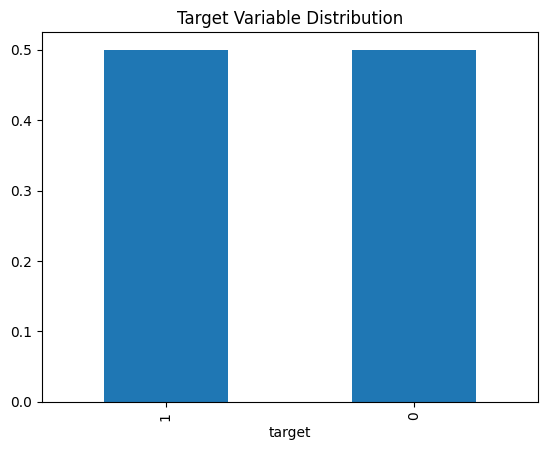

In [10]:
df_balanced['target'].value_counts(normalize=True).plot(kind='bar', title='Target Variable Distribution')
plt.show()

In [22]:
df_balanced.head()

,ip,app,device,os,channel,click_time,target
0,81211,11,1,19,173,2017-11-08 22:53:55,1
1,73516,18,1,40,107,2017-11-08 11:11:48,0
2,106279,18,1,19,121,2017-11-08 13:18:24,1
3,7441,172,1,20,414,2017-11-07 00:59:43,1
4,55931,2,1,19,477,2017-11-06 16:18:26,0


In [23]:
#Feature Engineering

In [10]:
# Ensure 'click_time' is in datetime format in df_balanced
df_balanced['click_time'] = pd.to_datetime(df_balanced['click_time'])

# Extract  hour, and minute

df_balanced['hour'] = df_balanced['click_time'].dt.hour
df_balanced['minute'] = df_balanced['click_time'].dt.minute


In [11]:
df_balanced.head()


,ip,app,device,os,channel,click_time,target,hour,minute
0,81211,11,1,19,173,2017-11-08 22:53:55,1,22,53
1,73516,18,1,40,107,2017-11-08 11:11:48,0,11,11
2,106279,18,1,19,121,2017-11-08 13:18:24,1,13,18
3,7441,172,1,20,414,2017-11-07 00:59:43,1,0,59
4,55931,2,1,19,477,2017-11-06 16:18:26,0,16,18


In [12]:
# Ensure 'click_time' is in datetime format
df_balanced['click_time'] = pd.to_datetime(df_balanced['click_time'])

# Extract the day name (e.g., Monday, Tuesday)
df_balanced['day_name'] = df_balanced['click_time'].dt.day_name()


In [13]:
df_balanced

,ip,app,device,os,channel,click_time,target,hour,minute,day_name
0,81211,11,1,19,173,2017-11-08 22:53:55,1,22,53,Wednesday
1,73516,18,1,40,107,2017-11-08 11:11:48,0,11,11,Wednesday
2,106279,18,1,19,121,2017-11-08 13:18:24,1,13,18,Wednesday
3,7441,172,1,20,414,2017-11-07 00:59:43,1,0,59,Tuesday
4,55931,2,1,19,477,2017-11-06 16:18:26,0,16,18,Monday
...,...,...,...,...,...,...,...,...,...,...
913687,88143,18,1,22,121,2017-11-09 12:22:03,0,12,22,Thursday
913688,75979,14,1,3,349,2017-11-09 07:18:17,0,7,18,Thursday
913689,4405,9,1,19,127,2017-11-08 15:41:43,0,15,41,Wednesday
913690,239580,45,1,20,5,2017-11-08 04:50:46,1,4,50,Wednesday


In [13]:
df_balanced['day_name'].value_counts()

day_name
Wednesday    308593
Tuesday      299393
Thursday     265175
Monday        40531
Name: count, dtype: int64

Creating features like **day**, **hour**, and **minute** from the `click_time` timestamp helps capture time-dependent patterns in user behavior, which are crucial for understanding when users are most likely to interact with ads or apps. The **day of the week** reveals weekly trends, showing if users are more active on certain days (e.g., weekends vs weekdays). The **hour of the day** captures daily fluctuations in activity, helping identify peak times for user engagement, while the **minute** level offers finer granularity, useful for understanding real-time interactions or quick event sequences. Including these features improves model performance by allowing it to learn time-based trends, optimize ad targeting, and predict user behavior more accurately based on when the action occurs.


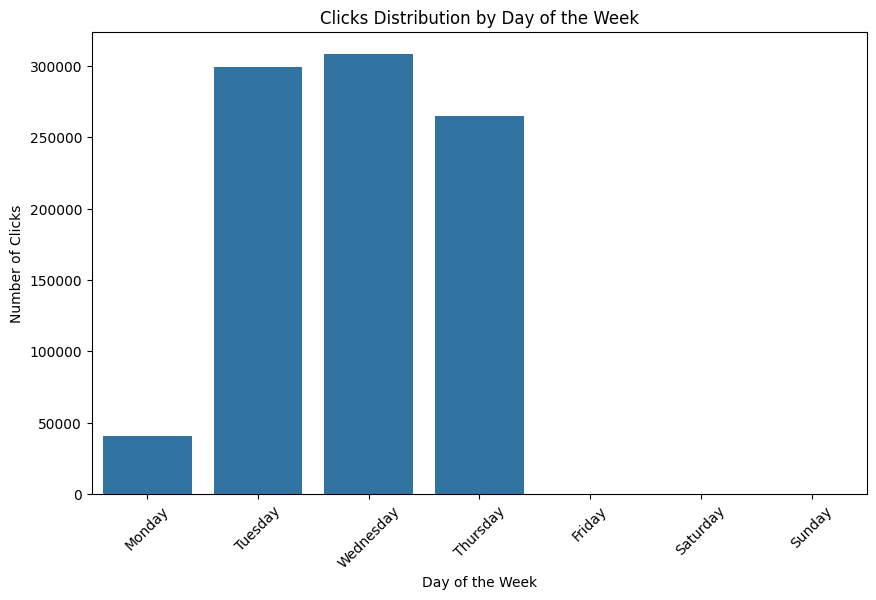

In [40]:
# 1. Distribution of Clicks by Day of the Week
plt.figure(figsize=(10, 6))
sn.countplot(data=df_balanced, x='day_name', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Clicks Distribution by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45)
plt.show()


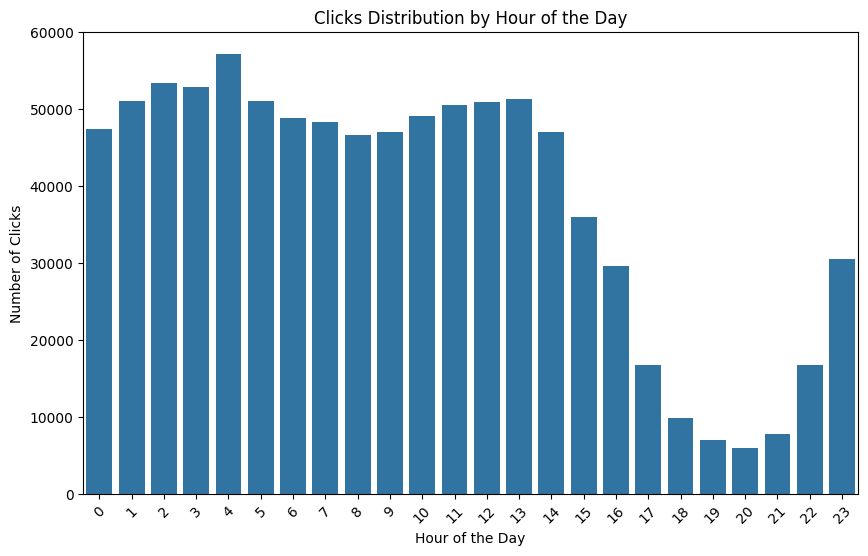

In [41]:
# 3. Clicks by Hour of the Day
plt.figure(figsize=(10, 6))
sn.countplot(data=df_balanced, x='hour')
plt.title('Clicks Distribution by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45)
plt.show()


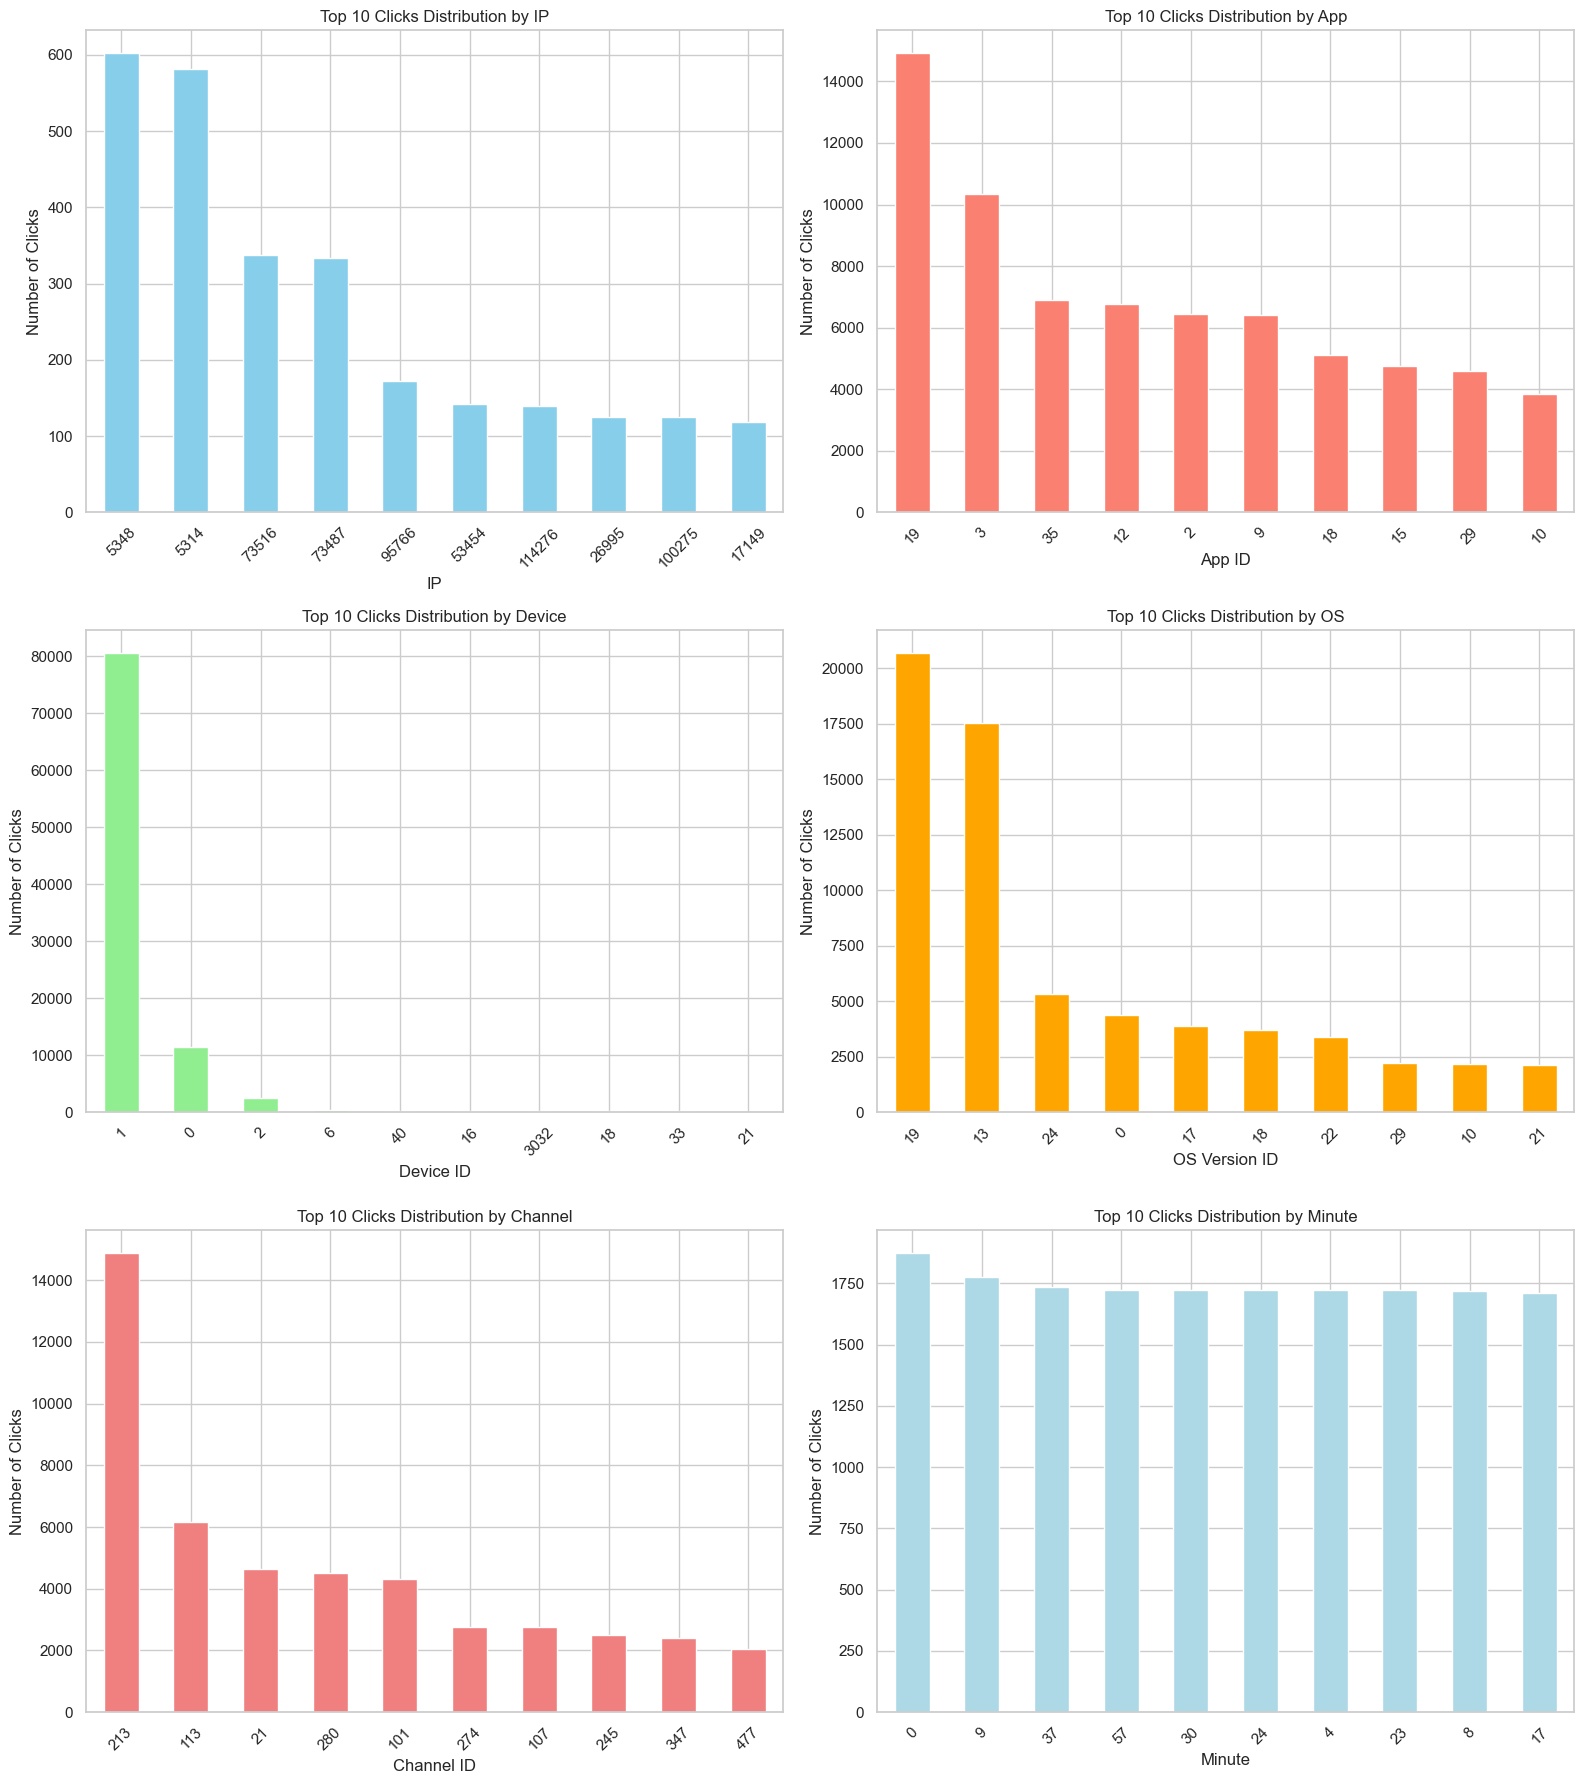

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Set plot style
plt.style.use('seaborn-v0_8-colorblind')

# Sample the data (if needed, adjust sample size as required)
df_sampled = df_balanced.sample(n=100000, random_state=42)  # Take a random sample of 10,000 rows

# Create a figure with multiple subplots (3 rows x 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))  # 3x2 grid for subplots

# Plot Distribution of Clicks by IP (Top 10 IPs)
df_sampled['ip'].value_counts().nlargest(10).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Top 10 Clicks Distribution by IP')
axes[0, 0].set_xlabel('IP')
axes[0, 0].set_ylabel('Number of Clicks')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot Distribution of Clicks by App (Top 10 Apps)
df_sampled['app'].value_counts().nlargest(10).plot(kind='bar', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Top 10 Clicks Distribution by App')
axes[0, 1].set_xlabel('App ID')
axes[0, 1].set_ylabel('Number of Clicks')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot Distribution of Clicks by Device (Top 10 Devices)
df_sampled['device'].value_counts().nlargest(10).plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Top 10 Clicks Distribution by Device')
axes[1, 0].set_xlabel('Device ID')
axes[1, 0].set_ylabel('Number of Clicks')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot Distribution of Clicks by OS (Top 10 OS Versions)
df_sampled['os'].value_counts().nlargest(10).plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Top 10 Clicks Distribution by OS')
axes[1, 1].set_xlabel('OS Version ID')
axes[1, 1].set_ylabel('Number of Clicks')
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot Distribution of Clicks by Channel (Top 10 Channels)
df_sampled['channel'].value_counts().nlargest(10).plot(kind='bar', ax=axes[2, 0], color='lightcoral')
axes[2, 0].set_title('Top 10 Clicks Distribution by Channel')
axes[2, 0].set_xlabel('Channel ID')
axes[2, 0].set_ylabel('Number of Clicks')
axes[2, 0].tick_params(axis='x', rotation=45)

# Plot Distribution of Clicks by Minute (Top 10 Minutes)
df_sampled['minute'].value_counts().nlargest(10).plot(kind='bar', ax=axes[2, 1], color='lightblue')
axes[2, 1].set_title('Top 10 Clicks Distribution by Minute')
axes[2, 1].set_xlabel('Minute')
axes[2, 1].set_ylabel('Number of Clicks')
axes[2, 1].tick_params(axis='x', rotation=45)

# Adjust the layout to avoid overlap
plt.tight_layout()
plt.show()



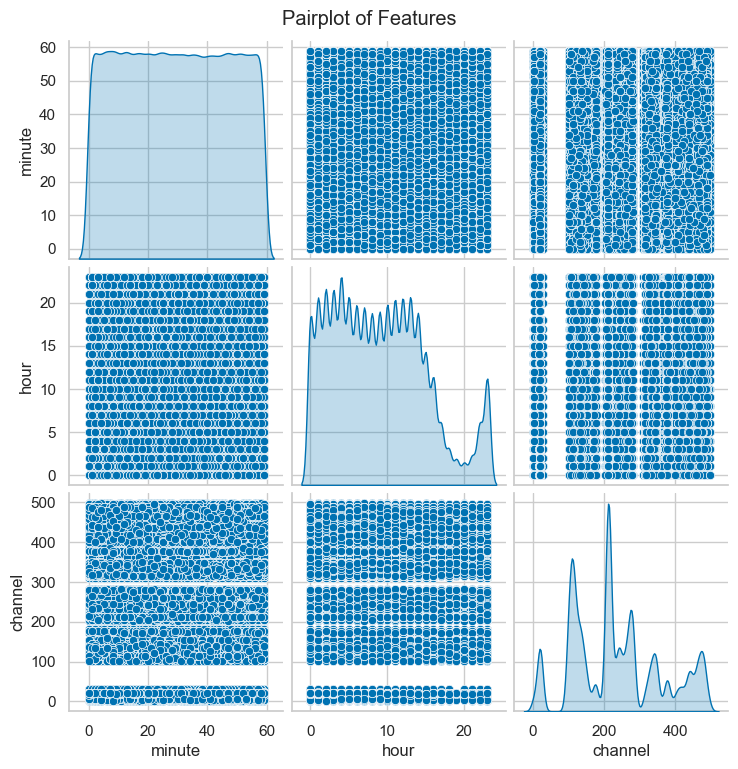

In [51]:
# Create a pairplot to visualize relationships between 'minute', 'hour', 'day', and 'channel'
sns.pairplot(df_balanced[['minute', 'hour', 'day_name', 'channel']], diag_kind='kde')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()


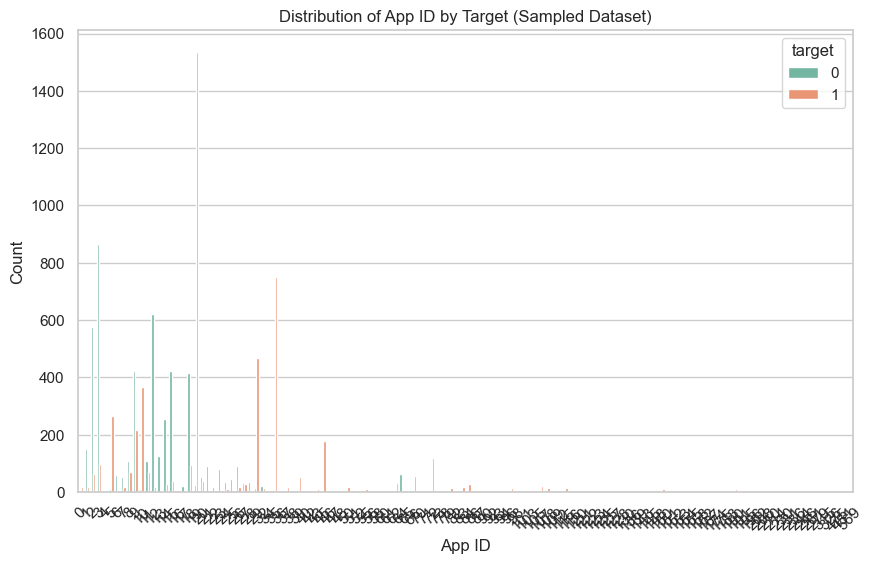

In [55]:
# Plot distribution of 'app' by target (sampled dataset)
df_sampled = df_balanced.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
sns.countplot(x='app', hue='target', data=df_sampled, palette='Set2')
plt.title('Distribution of App ID by Target (Sampled Dataset)')
plt.xlabel('App ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()



C:\Users\1033\AppData\Local\Temp\ipykernel_28700\2527577865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='minute', data=df_sampled, palette='coolwarm')


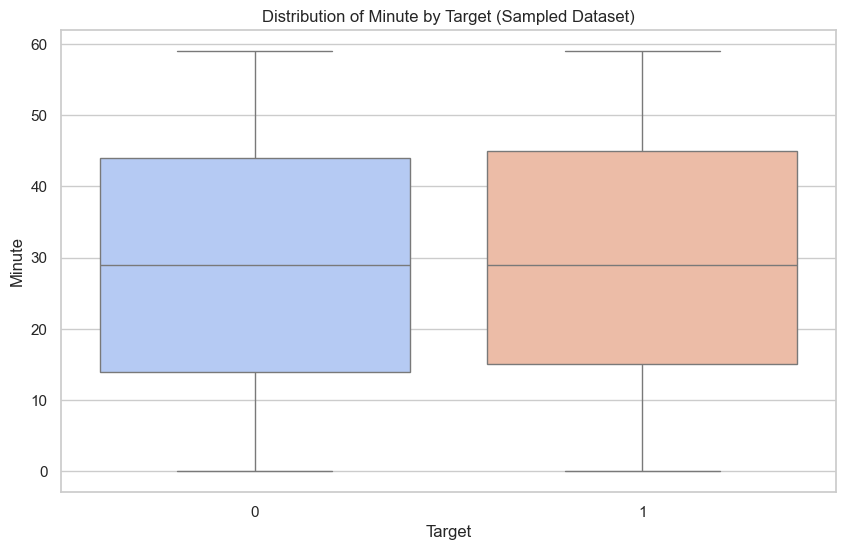

In [56]:
# Box plot for 'minute' by 'target' (sampled dataset)
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='minute', data=df_sampled, palette='coolwarm')
plt.title('Distribution of Minute by Target (Sampled Dataset)')
plt.xlabel('Target')
plt.ylabel('Minute')
plt.show()


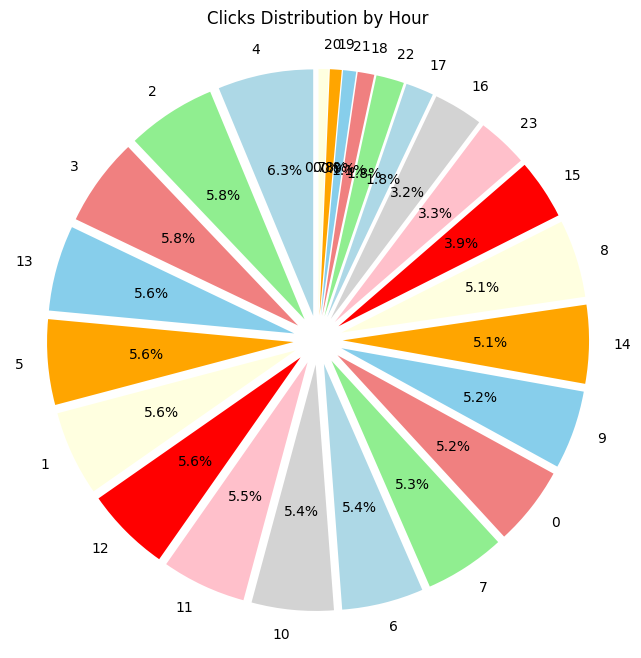

In [14]:
# Pie chart for the 'hour' column (distribution of clicks by hour)
hour_counts = df_balanced['hour'].value_counts()

plt.figure(figsize=(8, 8))
hour_counts.plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral', 'skyblue', 'orange', 'lightyellow', 'red', 'pink', 'lightgrey'], startangle=90, explode=[0.1] * len(hour_counts))
plt.title('Clicks Distribution by Hour')
plt.ylabel('')  # Hide the y-label
plt.show()


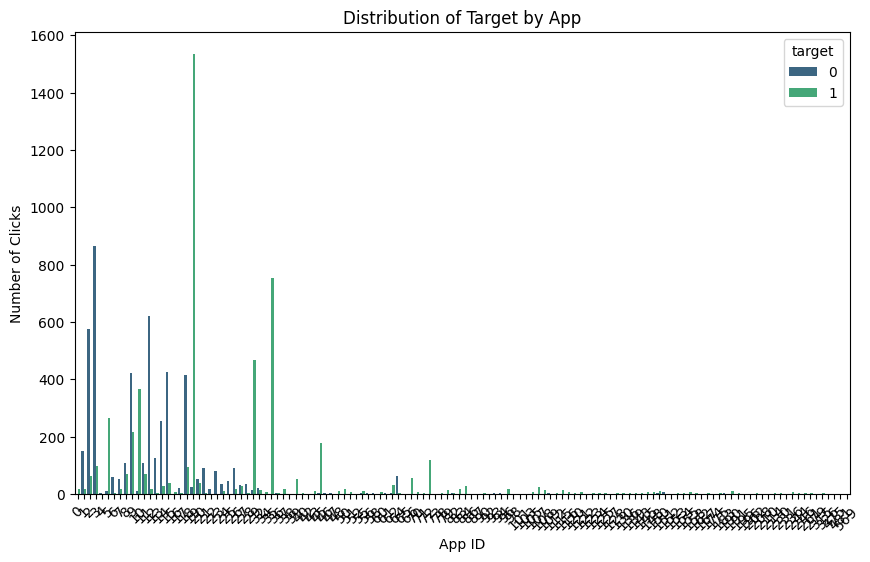

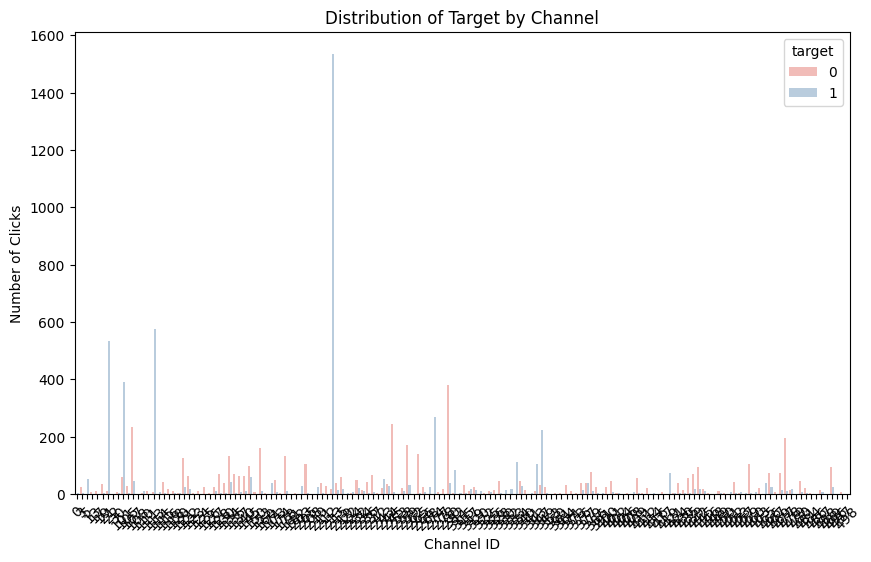

In [20]:
# Plot distribution of 'app' by target (sampled dataset)
df_sampled = df_balanced.sample(n=10000, random_state=42)



# Bar plot for distribution of 'target' by 'app'
plt.figure(figsize=(10, 6))
sn.countplot(x='app', hue='target', data=df_sampled, palette='viridis')
plt.title('Distribution of Target by App')
plt.xlabel('App ID')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45)
plt.show()



# Bar plot for distribution of 'target' by 'channel'
plt.figure(figsize=(10, 6))
sn.countplot(x='channel', hue='target', data=df_sampled, palette='Pastel1')
plt.title('Distribution of Target by Channel')
plt.xlabel('Channel ID')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45)
plt.show()



In [21]:
# Correlation Plot

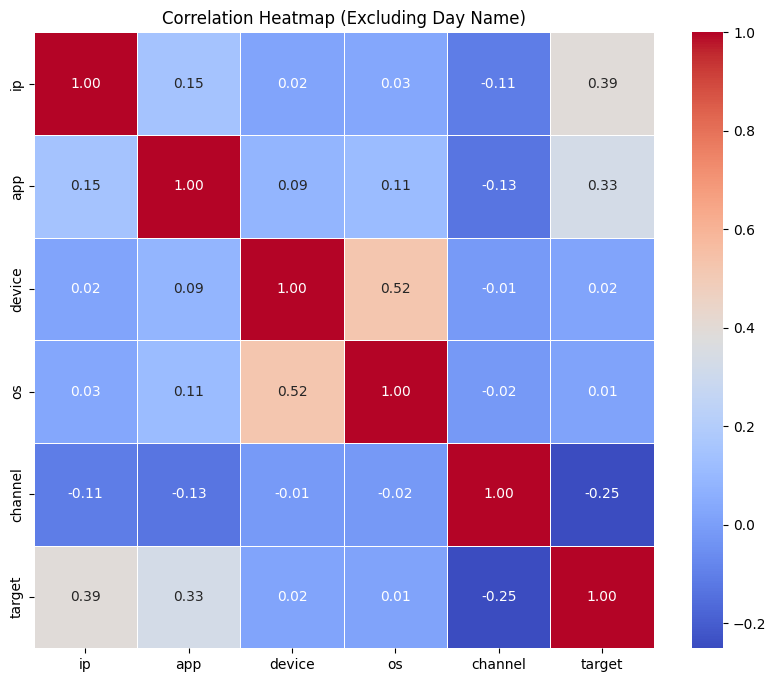

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns (excluding 'day_name')
numeric_cols = df_balanced.select_dtypes(include=['float64', 'int64']).columns

# Compute correlation matrix
correlation_matrix = df_balanced[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Correlation Heatmap (Excluding Day Name)')
plt.show()


Removing click_time and day_name from the dataset is a strategy to simplify the feature set and focus on more impactful variables. click_time has been partially encoded through the extraction of hour and minute, which capture relevant time patterns (e.g., peak hours of activity), making the full timestamp redundant. On the other hand, day_name might not provide significant predictive value if there's no strong trend based on the day of the week, such as varying click patterns between weekdays and weekends. By removing these features, you're reducing data complexity, improving model training speed, and preventing potential overfitting, while retaining the key factors (e.g., ip, app, device, hour, minute) that are more directly related to the target variable.



In [14]:
# Remove 'click_time' and 'day_name' columns
df_balanced = df_balanced.drop(columns=['click_time', 'day_name'])

# Verify the columns are removed
print(df_balanced.columns)


Index(['ip', 'app', 'device', 'os', 'channel', 'target', 'hour', 'minute'], dtype='object')


In [15]:
df_balanced.to_csv('Sampleddataset.csv')

Devide Dataset into input and output

In [7]:
# Define the feature set (X) and target variable (y)
X = df_balanced.drop(columns=['target'])  
y = df_balanced['target']  



In [8]:
print(X.shape,y.shape)

(913692, 7) (913692,)


In [9]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Verify the shapes of the split data
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (685269, 7)
X_test shape: (228423, 7)
y_train shape: (685269,)
y_test shape: (228423,)


Apply scaler

In [10]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Apply MinMax Scaler to the features
scaler = MinMaxScaler()

# Fit and transform the training data, and transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for future use
joblib.dump(scaler, 'minmax_scaler.pkl')

['minmax_scaler.pkl']

#Algorithms Apply

Training Logistic Regression...

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.75      0.81      0.78    114149
           1       0.79      0.73      0.76    114274

    accuracy                           0.77    228423
   macro avg       0.77      0.77      0.77    228423
weighted avg       0.77      0.77      0.77    228423



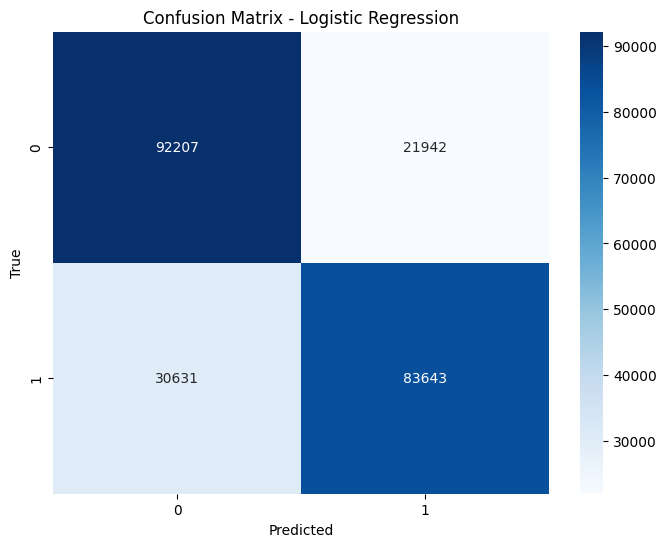

Logistic Regression model saved as Logistic Regression_model.pkl
Training Decision Tree...

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88    114149
           1       0.88      0.88      0.88    114274

    accuracy                           0.88    228423
   macro avg       0.88      0.88      0.88    228423
weighted avg       0.88      0.88      0.88    228423



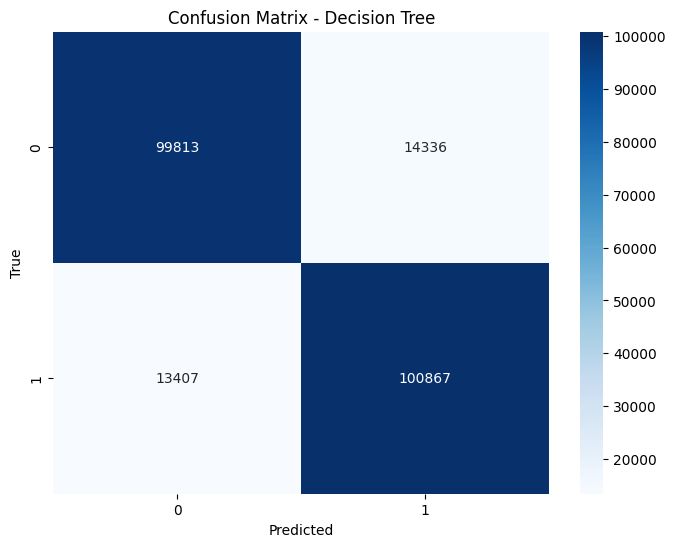

Decision Tree model saved as Decision Tree_model.pkl
Training Random Forest...

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.89      0.95      0.92    114149
           1       0.95      0.88      0.91    114274

    accuracy                           0.92    228423
   macro avg       0.92      0.92      0.92    228423
weighted avg       0.92      0.92      0.92    228423



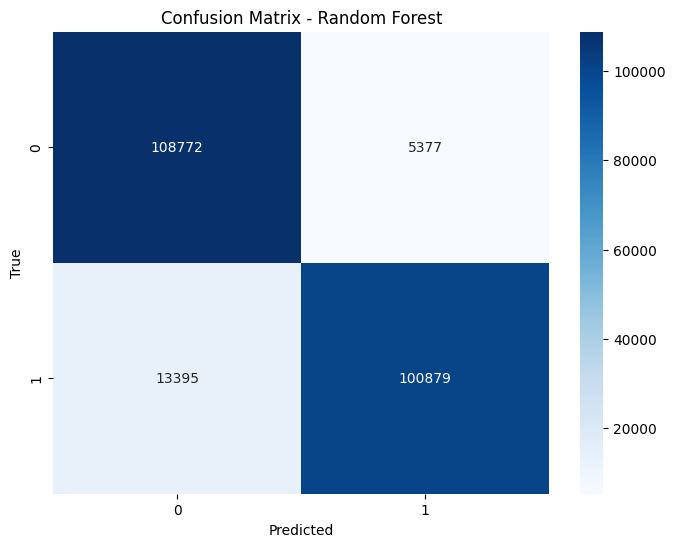

Random Forest model saved as Random Forest_model.pkl
Training KNN...

Classification Report for KNN:

              precision    recall  f1-score   support

           0       0.83      0.86      0.84    114149
           1       0.86      0.82      0.84    114274

    accuracy                           0.84    228423
   macro avg       0.84      0.84      0.84    228423
weighted avg       0.84      0.84      0.84    228423



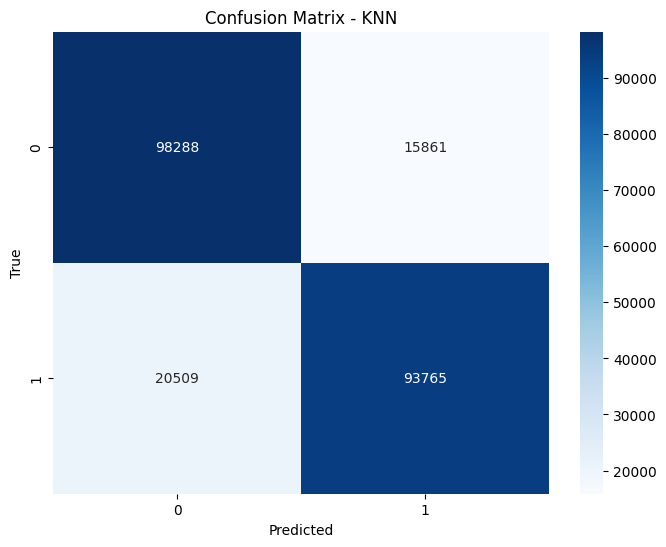

KNN model saved as KNN_model.pkl
Training Naive Bayes...

Classification Report for Naive Bayes:

              precision    recall  f1-score   support

           0       0.69      0.89      0.78    114149
           1       0.85      0.61      0.71    114274

    accuracy                           0.75    228423
   macro avg       0.77      0.75      0.74    228423
weighted avg       0.77      0.75      0.74    228423



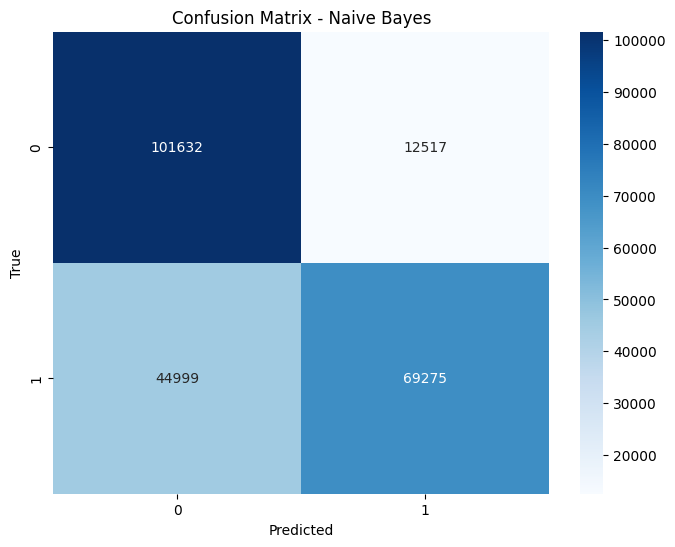

Naive Bayes model saved as Naive Bayes_model.pkl
Training Gradient Boosting...

Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.87      0.97      0.91    114149
           1       0.96      0.85      0.90    114274

    accuracy                           0.91    228423
   macro avg       0.91      0.91      0.91    228423
weighted avg       0.91      0.91      0.91    228423



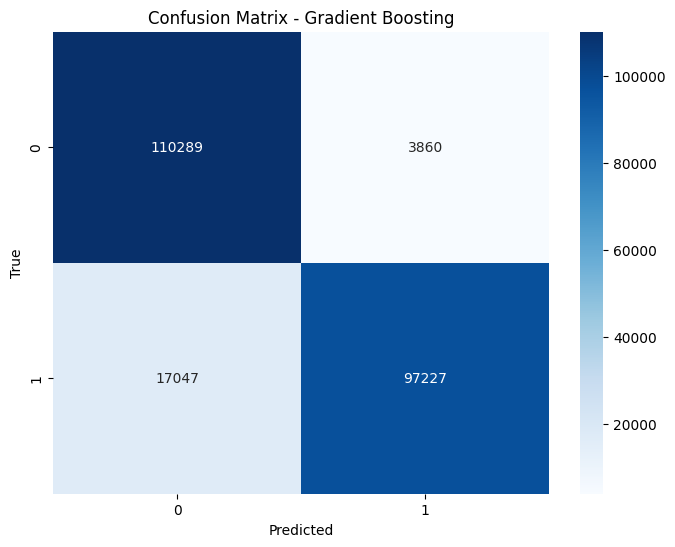

Gradient Boosting model saved as Gradient Boosting_model.pkl
Training LightGBM...

[LightGBM] [Info] Number of positive: 342572, number of negative: 342697
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002558 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1043
[LightGBM] [Info] Number of data points in the train set: 685269, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499909 -> initscore=-0.000365
[LightGBM] [Info] Start training from score -0.000365


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.89      0.96      0.92    114149
           1       0.96      0.88      0.92    114274

    accuracy                           0.92    228423
   macro avg       0.92      0.92      0.92    228423
weighted avg       0.92      0.92      0.92    228423



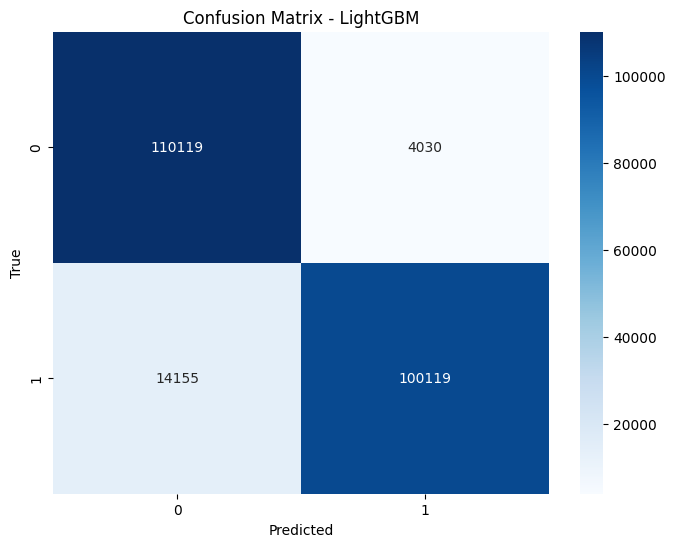

LightGBM model saved as LightGBM_model.pkl
Training XGBoost...

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.89      0.96      0.93    114149
           1       0.96      0.88      0.92    114274

    accuracy                           0.92    228423
   macro avg       0.93      0.92      0.92    228423
weighted avg       0.93      0.92      0.92    228423



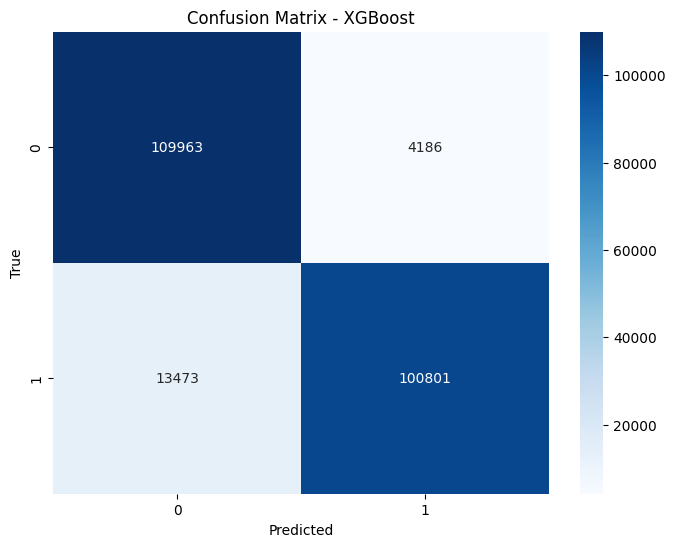

XGBoost model saved as XGBoost_model.pkl


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
from keras.models import Sequential
from keras.layers import Dense, LSTM, Conv2D, Flatten
from sklearn.preprocessing import StandardScaler
import joblib  # for saving models



# List of models to train
models = [
    ('Logistic Regression', LogisticRegression()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('KNN', KNeighborsClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('LightGBM', lgb.LGBMClassifier()),
    ('XGBoost', xgb.XGBClassifier())
]

# Function to plot classification report and confusion matrix and save the model
def plot_metrics(model, X_test_scaled, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Classification Report
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    # Save the trained model
    joblib.dump(model, f'{model_name}_model.pkl')
    print(f"{model_name} model saved as {model_name}_model.pkl")


# Train models and plot metrics
for name, model in models:
    print(f"Training {name}...\n")
    model.fit(X_train_scaled, y_train)
    plot_metrics(model, X_test_scaled, y_test, name)

In [ ]:
# 0: Non-fraudulent click (i.e., the click is legitimate).

# 1: Fraudulent click (i.e., the click is a fraudulent or suspicious click, likely from a bot or an abnormal pattern).

# Ann,Cnn,Rnn

Epoch 1/10
21415/21415 [==============================] - 16s 724us/step - loss: 0.3866 - accuracy: 0.8403
Epoch 2/10
21415/21415 [==============================] - 17s 789us/step - loss: 0.3047 - accuracy: 0.8843
Epoch 3/10
21415/21415 [==============================] - 17s 798us/step - loss: 0.2857 - accuracy: 0.8909
Epoch 4/10
21415/21415 [==============================] - 17s 811us/step - loss: 0.2757 - accuracy: 0.8932
Epoch 5/10
21415/21415 [==============================] - 17s 772us/step - loss: 0.2664 - accuracy: 0.8958
Epoch 6/10
21415/21415 [==============================] - 16s 737us/step - loss: 0.2603 - accuracy: 0.8985
Epoch 7/10
21415/21415 [==============================] - 16s 746us/step - loss: 0.2561 - accuracy: 0.9000
Epoch 8/10
21415/21415 [==============================] - 17s 806us/step - loss: 0.2535 - accuracy: 0.9008
Epoch 9/10
21415/21415 [==============================] - 16s 750us/step - loss: 0.2510 - accuracy: 0.9022
Epoch 10/10
7139/7139 [==============

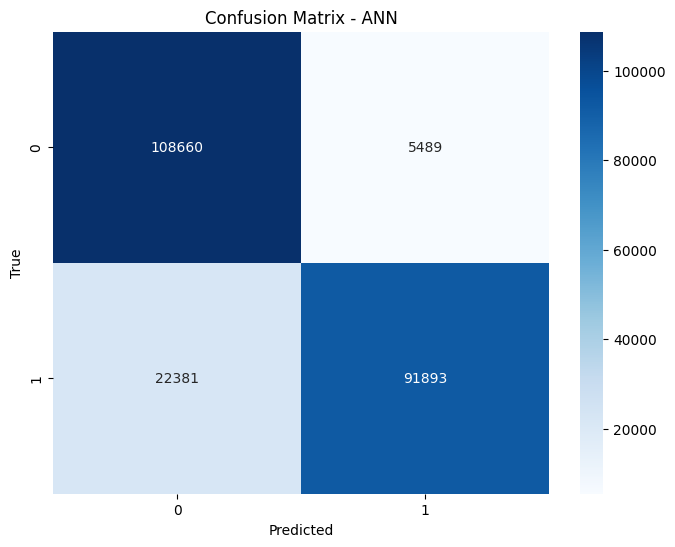

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, LSTM
from keras.optimizers import Adam

# Assuming you have already scaled the data
# X_train_scaled, X_test_scaled, y_train, y_test

# 1. ANN (Artificial Neural Network)
ann_model = Sequential()
ann_model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))
ann_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train ANN
ann_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, verbose=1)
y_pred_ann = (ann_model.predict(X_test_scaled) > 0.5).astype(int)

# ANN Classification Report
print("ANN Classification Report:\n")
print(classification_report(y_test, y_pred_ann))

# Confusion Matrix for ANN
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - ANN")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




In [18]:
# Save the trained ANN model
ann_model.save('ANN_model.h5')
print("ANN model saved as ANN_model.h5")


ANN model saved as ANN_model.h5


c:\Users\1033\.conda\envs\envs\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 1/10
21415/21415 [==============================] - 21s 971us/step - loss: 0.4082 - accuracy: 0.8280
Epoch 2/10
21415/21415 [==============================] - 21s 991us/step - loss: 0.3351 - accuracy: 0.8717
Epoch 3/10
21415/21415 [==============================] - 21s 975us/step - loss: 0.3180 - accuracy: 0.8781
Epoch 4/10
21415/21415 [==============================] - 21s 974us/step - loss: 0.3075 - accuracy: 0.8824
Epoch 5/10
21415/21415 [==============================] - 21s 974us/step - loss: 0.2993 - accuracy: 0.8852
Epoch 6/10
21415/21415 [==============================] - 21s 972us/step - loss: 0.2936 - accuracy: 0.8871
Epoch 7/10
21415/21415 [==============================] - 21s 971us/step - loss: 0.2883 - accuracy: 0.8890
Epoch 8/10
21415/21415 [==============================] - 21s 969us/step - loss: 0.2823 - accuracy: 0.8908
Epoch 9/10
21415/21415 [==============================] - 21s 969us/step - loss: 0.2739 - accuracy: 0.8935
Epoch 10/10
7139/7139 [=============

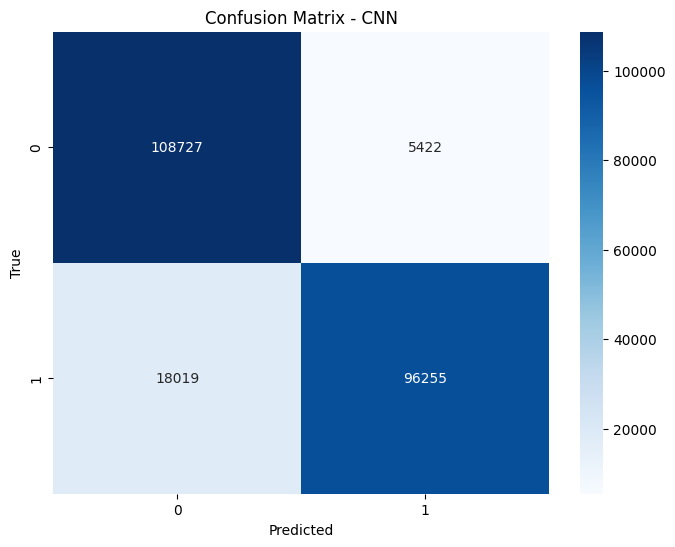

In [15]:
# Reshape the data for Conv2D (assuming 7 features and 1 channel)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], 7, 1, 1)  # (samples, height, width, channels)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], 7, 1, 1)

# Define the CNN Model with Conv2D
cnn_model = Sequential()
cnn_model.add(Conv2D(32, (3, 1), activation='relu', input_shape=(7, 1, 1)))  # 2D convolution with filter size (3, 1)
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train CNN
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, verbose=1)

# Predict using CNN
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

# CNN Classification Report
print("CNN Classification Report:\n")
print(classification_report(y_test, y_pred_cnn))

# Confusion Matrix for CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - CNN")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [19]:
# Save the trained CNN model
cnn_model.save('CNN_model.h5')
print("CNN model saved as CNN_model.h5")


CNN model saved as CNN_model.h5


Epoch 1/10
21415/21415 [==============================] - 53s 2ms/step - loss: 0.4006 - accuracy: 0.8245
Epoch 2/10
21415/21415 [==============================] - 62s 3ms/step - loss: 0.2947 - accuracy: 0.8817
Epoch 3/10
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2726 - accuracy: 0.8918
Epoch 4/10
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2616 - accuracy: 0.8959
Epoch 5/10
21415/21415 [==============================] - 63s 3ms/step - loss: 0.2538 - accuracy: 0.8998
Epoch 6/10
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2486 - accuracy: 0.9021
Epoch 7/10
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2437 - accuracy: 0.9044
Epoch 8/10
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2402 - accuracy: 0.9058
Epoch 9/10
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2384 - accuracy: 0.9069
Epoch 10/10
7139/7139 [==============================] 

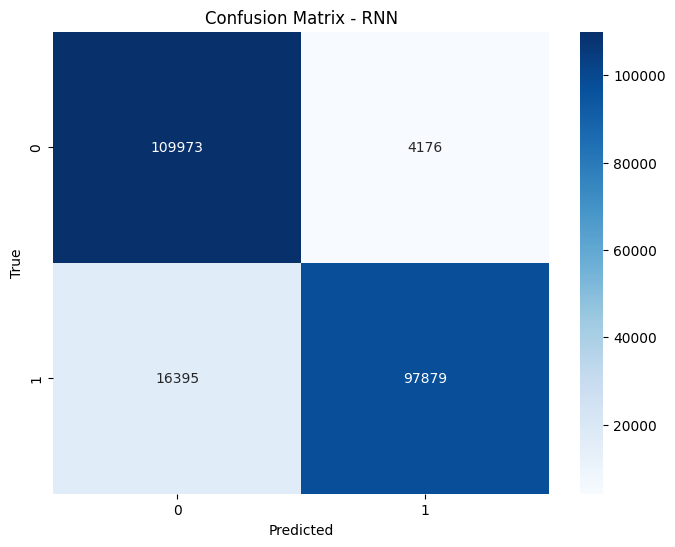

In [16]:
# Reshape the data for LSTM (3D shape: samples, timesteps, features)
X_train_rnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)  # 3D shape (samples, features, 1)
X_test_rnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Define the RNN Model (LSTM)
rnn_model = Sequential()
rnn_model.add(LSTM(128, input_shape=(X_train_rnn.shape[1], 1), activation='relu'))  # LSTM layer
rnn_model.add(Dense(64, activation='relu'))  # Dense hidden layer
rnn_model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the RNN
rnn_model.fit(X_train_rnn, y_train, epochs=10, batch_size=32, verbose=1)

# Predict using RNN
y_pred_rnn = (rnn_model.predict(X_test_rnn) > 0.5).astype(int)

# RNN Classification Report
print("RNN Classification Report:\n")
print(classification_report(y_test, y_pred_rnn))

# Confusion Matrix for RNN
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - RNN")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [20]:
# Save the trained RNN model
rnn_model.save('RNN_model.h5')
print("RNN model saved as RNN_model.h5")



RNN model saved as RNN_model.h5


# propossed models

Stacking classifier

In [40]:
df_balanced.columns

Index(['ip', 'app', 'device', 'os', 'channel', 'target', 'hour', 'minute'], dtype='object')

c:\Users\1033\.conda\envs\envs\lib\site-packages\xgboost\training.py:183: UserWarning: [14:39:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 342572, number of negative: 342697
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002478 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1043
[LightGBM] [Info] Number of data points in the train set: 685269, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499909 -> initscore=-0.000365
[LightGBM] [Info] Start training from score -0.000365


c:\Users\1033\.conda\envs\envs\lib\site-packages\xgboost\training.py:183: UserWarning: [14:41:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\1033\.conda\envs\envs\lib\site-packages\xgboost\training.py:183: UserWarning: [14:41:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\1033\.conda\envs\envs\lib\site-packages\xgboost\training.py:183: UserWarning: [14:41:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 274058, number of negative: 274157
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1051
[LightGBM] [Info] Number of data points in the train set: 548215, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499910 -> initscore=-0.000361
[LightGBM] [Info] Start training from score -0.000361


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Number of positive: 274057, number of negative: 274158
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 548215, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499908 -> initscore=-0.000368
[LightGBM] [Info] Start training from score -0.000368


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 274058, number of negative: 274158
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1049
[LightGBM] [Info] Number of data points in the train set: 548216, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499909 -> initscore=-0.000365
[LightGBM] [Info] Start training from score -0.000365


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stacking Classifier Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.95      0.92    114149
           1       0.95      0.89      0.92    114274

    accuracy                           0.92    228423
   macro avg       0.92      0.92      0.92    228423
weighted avg       0.92      0.92      0.92    228423



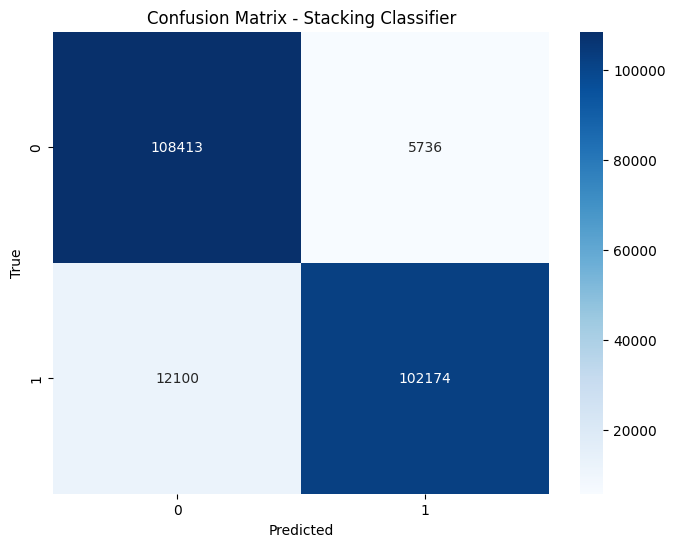

Stacking Classifier model saved as stacking_classifier_model.pkl
Stacking Classifier model loaded successfully.
Loaded model classification report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92    114149
           1       0.95      0.89      0.92    114274

    accuracy                           0.92    228423
   macro avg       0.92      0.92      0.92    228423
weighted avg       0.92      0.92      0.92    228423



c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU
from keras.optimizers import Adam
import joblib  # Importing joblib for saving the model

# Assuming X_train_scaled, X_test_scaled, y_train, y_test are already defined
# You can modify the following part with your actual data

# Base Learners for Stacking Classifier
base_learners = [
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('lgb', lgb.LGBMClassifier())
]

# Meta-model (Logistic Regression)
meta_model = LogisticRegression()

# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model)

# Train Stacking Classifier
stacking_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
y_pred_stack = stacking_model.predict(X_test_scaled)

# Stacking Classifier Classification Report
print("Stacking Classifier Classification Report:\n")
print(classification_report(y_test, y_pred_stack))

# Confusion Matrix for Stacking Classifier
cm_stack = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - Stacking Classifier")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Save the Stacking Classifier model
joblib.dump(stacking_model, 'stacking_classifier_model.pkl')
print("Stacking Classifier model saved as stacking_classifier_model.pkl")

# Loading the model (when needed)
loaded_model = joblib.load('stacking_classifier_model.pkl')
print("Stacking Classifier model loaded successfully.")

# Use the loaded model for prediction (optional)
y_pred_loaded_model = loaded_model.predict(X_test_scaled)
print("Loaded model classification report:\n", classification_report(y_test, y_pred_loaded_model))


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


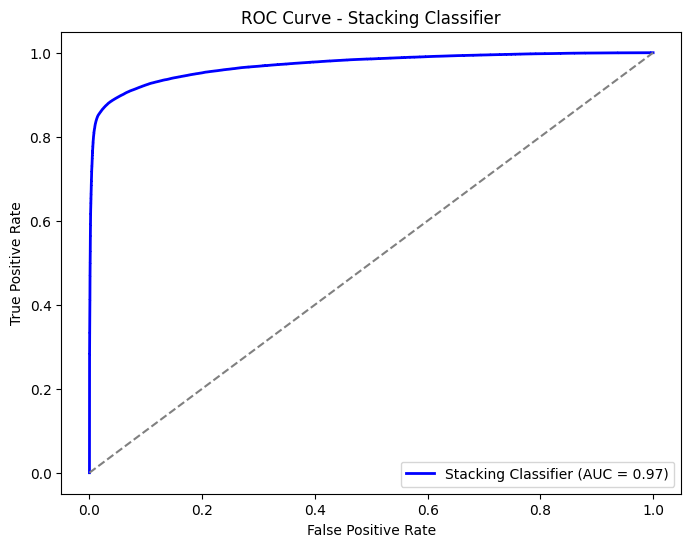

In [27]:
# ROC Curve for Stacking Classifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
y_pred_prob_stack = stacking_model.predict_proba(X_test_scaled)[:, 1] 
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_pred_prob_stack)
roc_auc_stack = auc(fpr_stack, tpr_stack)

# Plot ROC Curve for Stacking Classifier
plt.figure(figsize=(8, 6))
plt.plot(fpr_stack, tpr_stack, color='blue', lw=2, label=f'Stacking Classifier (AUC = {roc_auc_stack:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Classifier')
plt.legend(loc='lower right')
plt.show()

Epoch 1/20
21415/21415 [==============================] - 63s 3ms/step - loss: 0.4028 - accuracy: 0.8266
Epoch 2/20
21415/21415 [==============================] - 58s 3ms/step - loss: 0.2948 - accuracy: 0.8809
Epoch 3/20
21415/21415 [==============================] - 53s 2ms/step - loss: 0.2718 - accuracy: 0.8912
Epoch 4/20
21415/21415 [==============================] - 61s 3ms/step - loss: 0.2587 - accuracy: 0.8973
Epoch 5/20
21415/21415 [==============================] - 63s 3ms/step - loss: 0.2520 - accuracy: 0.9008
Epoch 6/20
21415/21415 [==============================] - 64s 3ms/step - loss: 0.2476 - accuracy: 0.9026
Epoch 7/20
21415/21415 [==============================] - 68s 3ms/step - loss: 0.2438 - accuracy: 0.9040
Epoch 8/20
21415/21415 [==============================] - 70s 3ms/step - loss: 0.2413 - accuracy: 0.9053
Epoch 9/20
21415/21415 [==============================] - 66s 3ms/step - loss: 0.2386 - accuracy: 0.9066
Epoch 10/20
21415/21415 [==============================

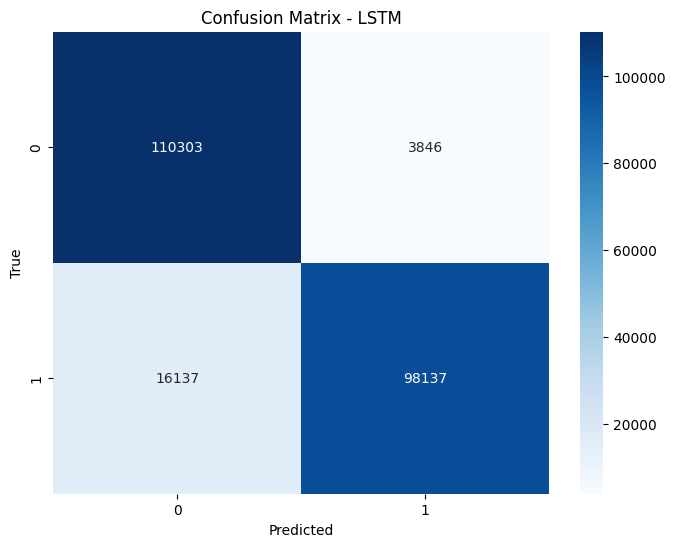

In [32]:

# ---------------------------------------
# 2. LSTM (Long Short-Term Memory)
# Reshaping the data for LSTM (3D array for LSTM input)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(X_train_lstm.shape[1], 1), activation='relu'))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))
lstm_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train LSTM
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, verbose=1)
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)

# LSTM Classification Report
print("LSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm))

# Confusion Matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - LSTM")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



7139/7139 [==============================] - 10s 1ms/step


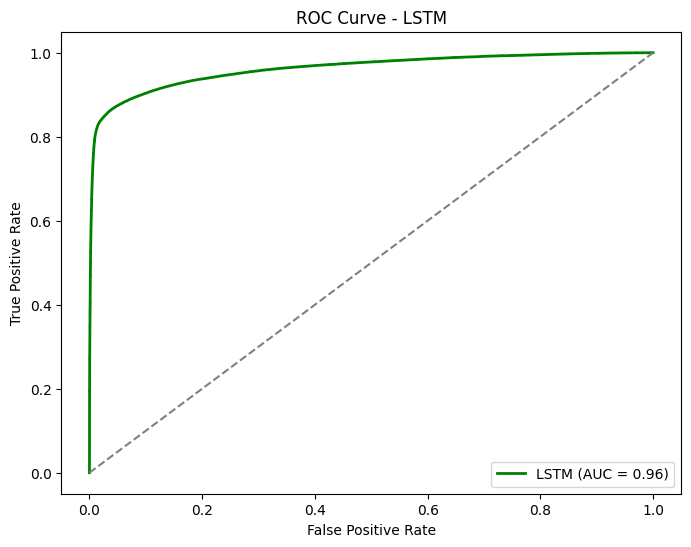

In [34]:
# LSTM model predictions and probabilities
y_pred_prob_lstm = lstm_model.predict(X_test_lstm)  # Assuming lstm_model is already trained
y_pred_prob_lstm = y_pred_prob_lstm.flatten()  # Flatten to make it a 1D array

# ROC Curve for LSTM
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# Plot ROC Curve for LSTM
plt.figure(figsize=(8, 6))
plt.plot(fpr_lstm, tpr_lstm, color='green', lw=2, label=f'LSTM (AUC = {roc_auc_lstm:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM')
plt.legend(loc='lower right')
plt.show()

In [33]:
# Save the trained RNN model
lstm_model.save('LSTM_model.h5')


c:\Users\1033\.conda\envs\envs\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/20
21415/21415 [==============================] - 58s 3ms/step - loss: 0.3812 - accuracy: 0.8349
Epoch 2/20
21415/21415 [==============================] - 59s 3ms/step - loss: 0.2849 - accuracy: 0.8857
Epoch 3/20
21415/21415 [==============================] - 51s 2ms/step - loss: 0.2644 - accuracy: 0.8955
Epoch 4/20
21415/21415 [==============================] - 46s 2ms/step - loss: 0.2536 - accuracy: 0.9005
Epoch 5/20
21415/21415 [==============================] - 46s 2ms/step - loss: 0.2470 - accuracy: 0.9032
Epoch 6/20
21415/21415 [==============================] - 46s 2ms/step - loss: 0.2421 - accuracy: 0.9053
Epoch 7/20
21415/21415 [==============================] - 45s 2ms/step - loss: 0.2388 - accuracy: 0.9063
Epoch 8/20
21415/21415 [==============================] - 45s 2ms/step - loss: 0.2364 - accuracy: 0.9074
Epoch 9/20
21415/21415 [==============================] - 46s 2ms/step - loss: 0.2343 - accuracy: 0.9083
Epoch 10/20
21415/21415 [==============================

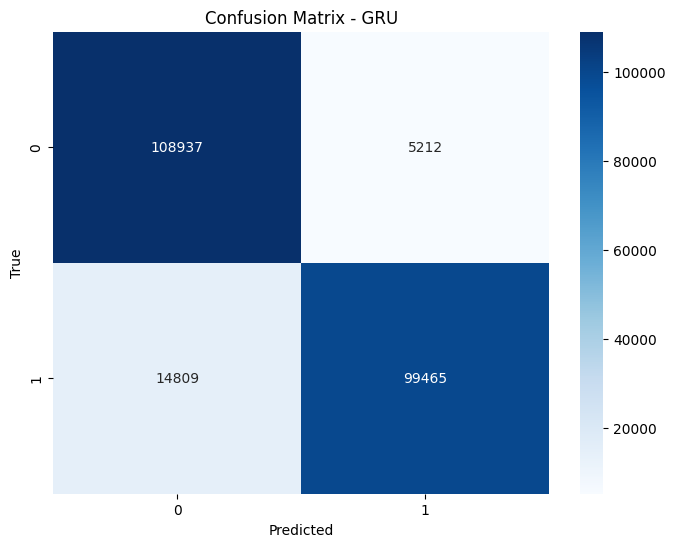

In [ ]:

# ---------------------------------------
# 3. GRU (Gated Recurrent Unit)
# Reshaping the data for GRU (3D array for GRU input)
X_train_gru = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_gru = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

gru_model = Sequential()
gru_model.add(GRU(128, input_shape=(X_train_gru.shape[1], 1), activation='relu'))
gru_model.add(Dense(64, activation='relu'))
gru_model.add(Dense(1, act  ivation='sigmoid'))
gru_model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train GRU
gru_model.fit(X_train_gru, y_train, epochs=20, batch_size=32, verbose=1)
y_pred_gru = (gru_model.predict(X_test_gru) > 0.5).astype(int)

# GRU Classification Report
print("GRU Classification Report:\n")
print(classification_report(y_test, y_pred_gru))

# Confusion Matrix for GRU
cm_gru = confusion_matrix(y_test, y_pred_gru)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - GRU")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()





In [30]:
# Save the trained RNN model
gru_model.save('gru_model.h5')

c:\Users\1033\.conda\envs\envs\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


7139/7139 [==============================] - 8s 1ms/step


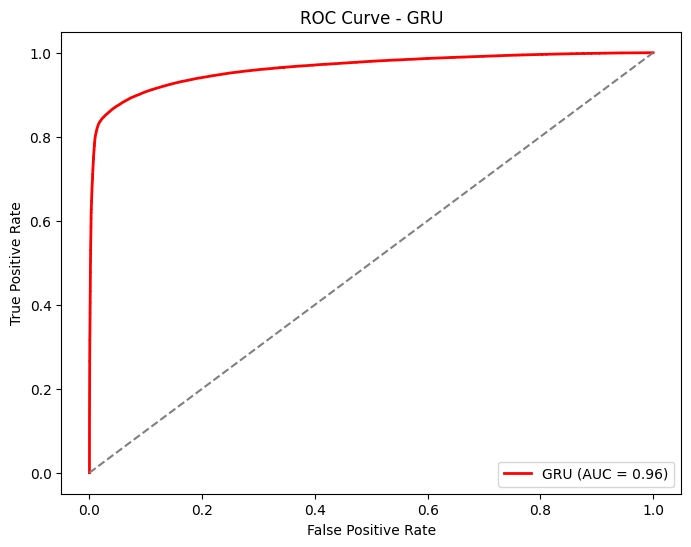

In [31]:
y_pred_prob_gru = gru_model.predict(X_test_gru) 
y_pred_prob_gru = y_pred_prob_gru.flatten()  # Flatten to make it a 1D array

# ROC Curve for GRU
fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_prob_gru)
roc_auc_gru = auc(fpr_gru, tpr_gru)

# Plot ROC Curve for GRU
plt.figure(figsize=(8, 6))
plt.plot(fpr_gru, tpr_gru, color='red', lw=2, label=f'GRU (AUC = {roc_auc_gru:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - GRU')
plt.legend(loc='lower right')
plt.show()



Model comparsion

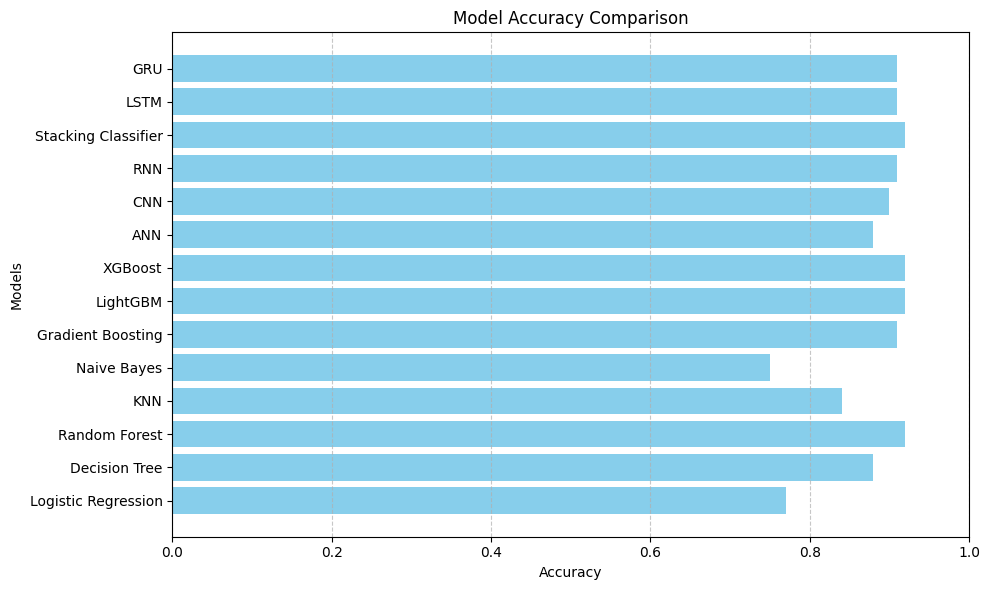

In [36]:
import matplotlib.pyplot as plt

# Accuracy values from the classification reports
accuracy_values = {
    'Logistic Regression': 0.77,
    'Decision Tree': 0.88,
    'Random Forest': 0.92,
    'KNN': 0.84,
    'Naive Bayes': 0.75,
    'Gradient Boosting': 0.91,
    'LightGBM': 0.92,
    'XGBoost': 0.92,
    'ANN': 0.88,
    'CNN': 0.90,
    'RNN': 0.91,
    'Stacking Classifier': 0.92,
    'LSTM': 0.91,
    'GRU': 0.91
}

# Plotting accuracy comparison
plt.figure(figsize=(10, 6))
plt.barh(list(accuracy_values.keys()), list(accuracy_values.values()), color='skyblue')
plt.xlabel('Accuracy')
plt.ylabel('Models')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)  # Accuracy ranges from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


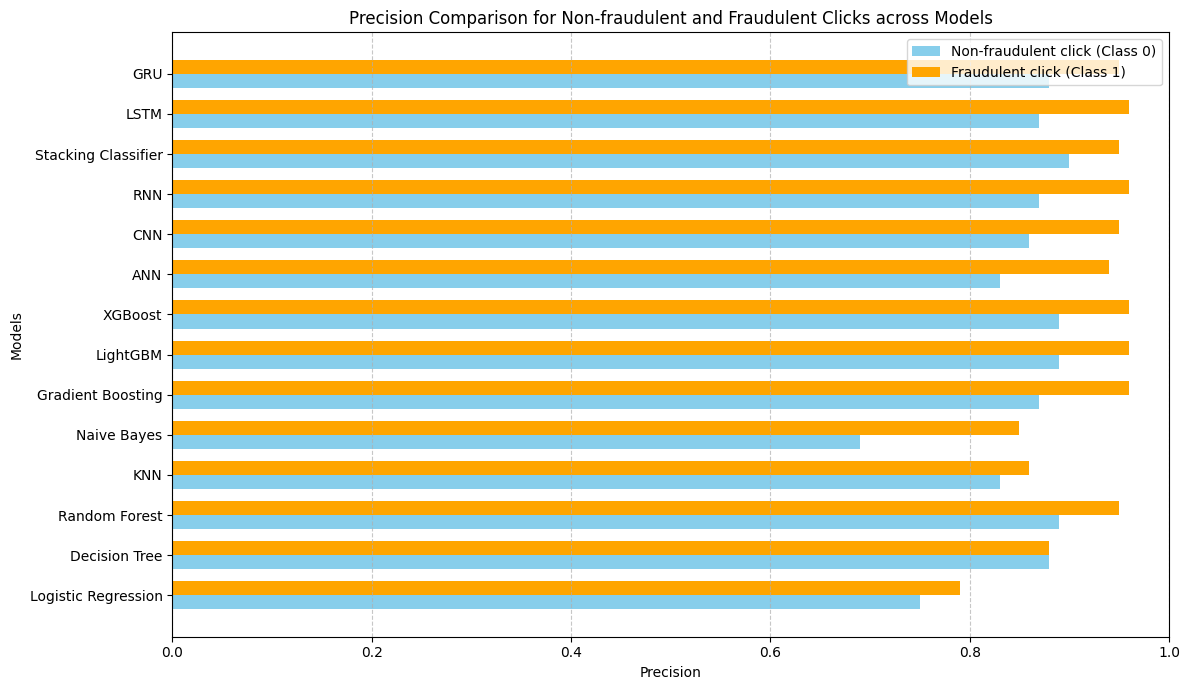

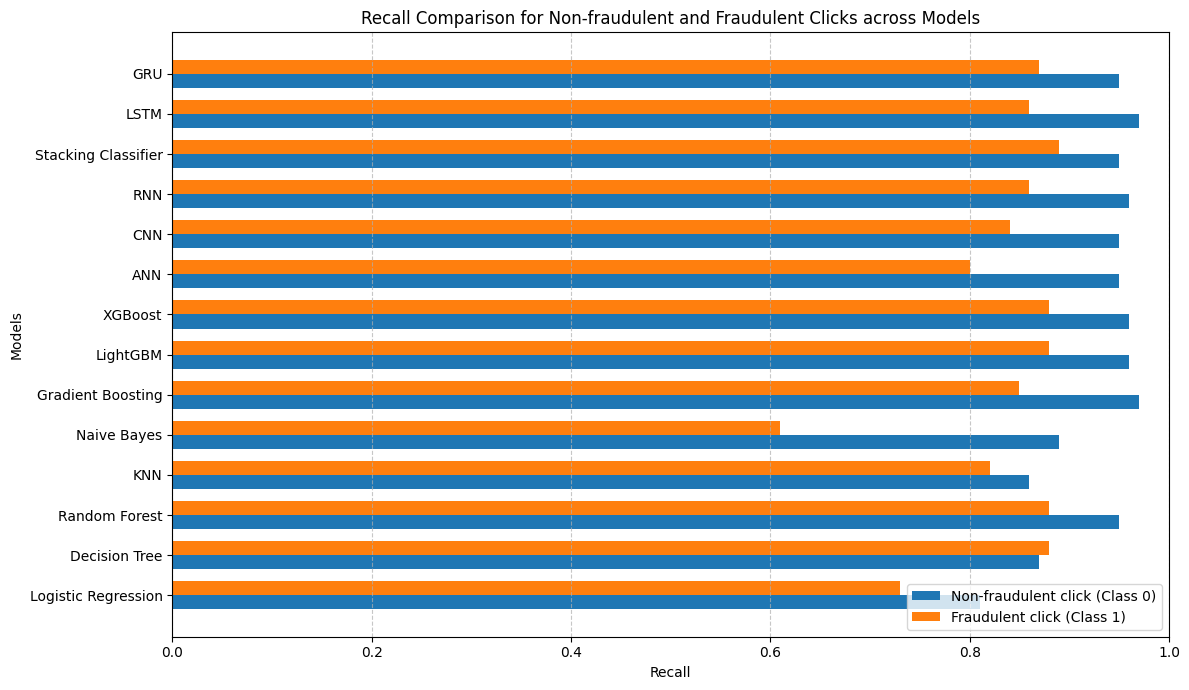

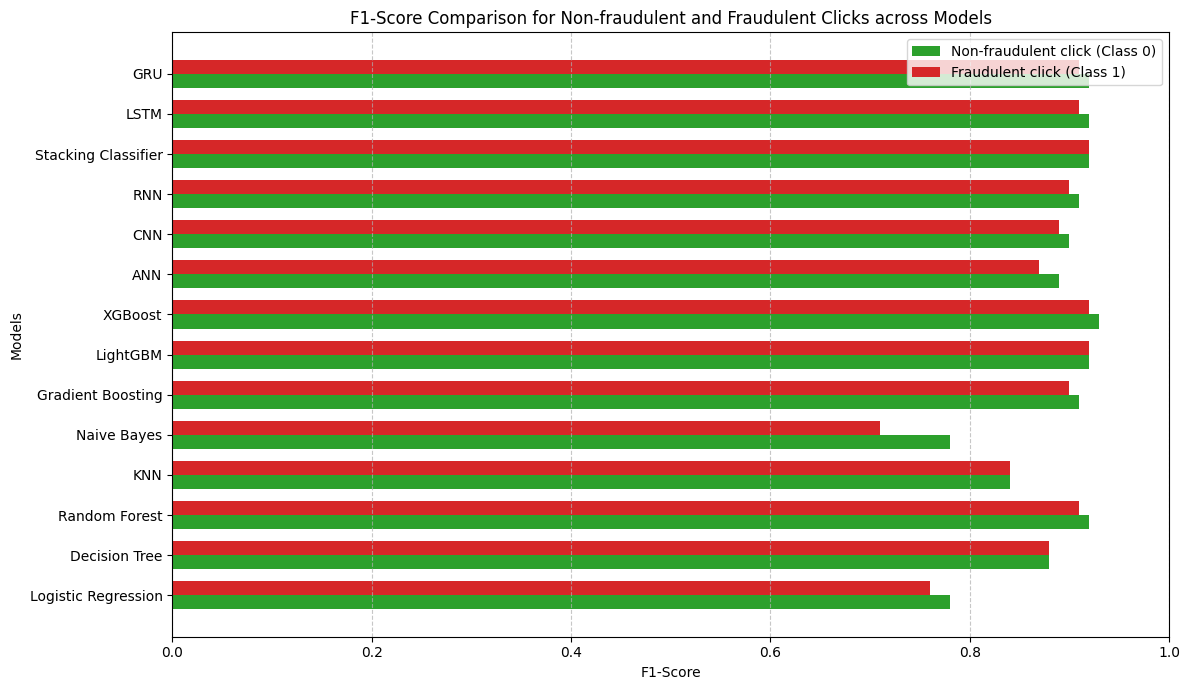

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Recall values for both classes (Non-fraudulent click and Fraudulent click)
recall_values = {
    'Logistic Regression': [0.81, 0.73],  # [Non-fraudulent, Fraudulent]
    'Decision Tree': [0.87, 0.88],
    'Random Forest': [0.95, 0.88],
    'KNN': [0.86, 0.82],
    'Naive Bayes': [0.89, 0.61],
    'Gradient Boosting': [0.97, 0.85],
    'LightGBM': [0.96, 0.88],
    'XGBoost': [0.96, 0.88],
    'ANN': [0.95, 0.80],
    'CNN': [0.95, 0.84],
    'RNN': [0.96, 0.86],
    'Stacking Classifier': [0.95, 0.89],
    'LSTM': [0.97, 0.86],
    'GRU': [0.95, 0.87]
}

# F1-score values for both classes (Non-fraudulent click and Fraudulent click)
f1_values = {
    'Logistic Regression': [0.78, 0.76],  # [Non-fraudulent, Fraudulent]
    'Decision Tree': [0.88, 0.88],
    'Random Forest': [0.92, 0.91],
    'KNN': [0.84, 0.84],
    'Naive Bayes': [0.78, 0.71],
    'Gradient Boosting': [0.91, 0.90],
    'LightGBM': [0.92, 0.92],
    'XGBoost': [0.93, 0.92],
    'ANN': [0.89, 0.87],
    'CNN': [0.90, 0.89],
    'RNN': [0.91, 0.90],
    'Stacking Classifier': [0.92, 0.92],
    'LSTM': [0.92, 0.91],
    'GRU': [0.92, 0.91]
}

# Prepare data for plotting
models = list(recall_values.keys())
non_fraudulent_recall = [values[0] for values in recall_values.values()]
fraudulent_recall = [values[1] for values in recall_values.values()]

non_fraudulent_f1 = [values[0] for values in f1_values.values()]
fraudulent_f1 = [values[1] for values in f1_values.values()]

# Set bar width and positions
bar_width = 0.35
index = np.arange(len(models))

# Plotting Recall for both classes
plt.figure(figsize=(12, 7))

# Set different colors for bars
bar1 = plt.barh(index, non_fraudulent_recall, bar_width, label='Non-fraudulent click (Class 0)', color='#1f77b4')  # Blue
bar2 = plt.barh(index + bar_width, fraudulent_recall, bar_width, label='Fraudulent click (Class 1)', color='#ff7f0e')  # Orange

# Labels and Titles
plt.xlabel('Recall')
plt.ylabel('Models')
plt.title('Recall Comparison for Non-fraudulent and Fraudulent Clicks across Models')
plt.yticks(index + bar_width / 2, models)
plt.xlim(0, 1)  # Recall ranges from 0 to 1

# Add legend
plt.legend()

# Show gridlines for clarity
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Plotting F1-Score for both classes
plt.figure(figsize=(12, 7))

# Set different colors for bars
bar1 = plt.barh(index, non_fraudulent_f1, bar_width, label='Non-fraudulent click (Class 0)', color='#2ca02c')  # Green
bar2 = plt.barh(index + bar_width, fraudulent_f1, bar_width, label='Fraudulent click (Class 1)', color='#d62728')  # Red

# Labels and Titles
plt.xlabel('F1-Score')
plt.ylabel('Models')
plt.title('F1-Score Comparison for Non-fraudulent and Fraudulent Clicks across Models')
plt.yticks(index + bar_width / 2, models)
plt.xlim(0, 1)  # F1-Score ranges from 0 to 1

# Add legend
plt.legend()

# Show gridlines for clarity
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


# prediction(gru)

Given that the **GRU model** was chosen as the final model, this decision is supported by its strong performance in recall, which is crucial for fraud detection tasks where detecting as many fraudulent clicks as possible is more important than avoiding false positives. The **GRU model** excels in identifying fraudulent clicks (Class 1), ensuring that the majority of fraudulent activities are flagged. While its precision is slightly lower compared to models like **Stacking Classifier** or **XGBoost**, this tradeoff is acceptable in fraud detection scenarios where the cost of missing fraudulent clicks (false negatives) is higher than the cost of false positives. Moreover, the **GRU model** is particularly well-suited for sequential data, which might provide an advantage in capturing temporal patterns in the click data, making it a more robust solution for real-time fraud detection applications. Thus, while it may not be the top performer in every metric, its ability to prioritize recall and capture complex patterns justifies its use as the final model for this task.


In [53]:
df_balanced.columns

Index(['ip', 'app', 'device', 'os', 'channel', 'target', 'hour', 'minute'], dtype='object')

In [49]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model  # Import for loading Keras model

# Load the saved GRU model and scaler
gru_model = load_model('gru_model.h5')  
scaler = joblib.load('minmax_scaler.pkl')  
12,246623,10,1,61,113,3,42
single_data = np.array([[246623, 10, 1, 61, 113, 3, 42]]) 

# Step 1: Apply the scaler to the single data point
single_data_scaled = scaler.transform(single_data)

# Step 2: Reshape the data for GRU input (3D array: [samples, time steps, features])
single_data_scaled_reshaped = single_data_scaled.reshape(1, single_data_scaled.shape[1], 1)

# Step 3: Predict using the GRU model
prediction = (gru_model.predict(single_data_scaled_reshaped) > 0.5).astype(int)

# Step 4: Print the prediction result
if prediction == 0:
    print("The prediction is: Non-fraudulent click (Class 0)")
else:
    print("The prediction is: Fraudulent click (Class 1)")


1/1 [==============================] - 0s 107ms/step
The prediction is: Fraudulent click (Class 1)


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
import numpy as np
from tensorflow.keras.models import load_model  # Import for loading Keras model

# Load the saved GRU model and scaler
gru_model = load_model('gru_model.h5')  
scaler = joblib.load('minmax_scaler.pkl')  

single_data = np.array([[114759, 2, 1, 58, 469, 13, 34]]) 

# Step 1: Apply the scaler to the single data point
single_data_scaled = scaler.transform(single_data)

# Step 2: Reshape the data for GRU input (3D array: [samples, time steps, features])
single_data_scaled_reshaped = single_data_scaled.reshape(1, single_data_scaled.shape[1], 1)

# Step 3: Predict using the GRU model
prediction = (gru_model.predict(single_data_scaled_reshaped) > 0.5).astype(int)

# Step 4: Print the prediction result
if prediction == 0:
    print("The prediction is: Non-fraudulent click (Class 0)")
else:
    print("The prediction is: Fraudulent click (Class 1)")


1/1 [==============================] - 0s 110ms/step
The prediction is: Non-fraudulent click (Class 0)


c:\Users\1033\.conda\envs\envs\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
